# Notebook: 04 Evaluation
### Purpose: load predictions, compute metrics, visualize overlays, and summarize performance.


In [1]:
import os
import sys


sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

import random

import cv2
import numpy as np
import torch

from src.data.annotations import load_json_annotations
from src.data.augmentations import get_val_augmentations
from src.data.loaders import ImageMaskDataset
from src.exploration.visualize import show_side_by_side
from src.models.zoo import MODEL_BUILDERS
from src.training.metrics import compute_metrics
from src.utils.config import Config
from src.utils.helpers import init_notebook, p, t


config = Config.load()

init_notebook(config.train.seed)

train_dir = config.paths.train_images
mask_dir = config.paths.train_masks
annotations_path = config.paths.annotations
entries = load_json_annotations(annotations_path)


None: None
=== init_notebook ===
Done


In [2]:
p("Models", MODEL_BUILDERS)
#config.show()
p("Batch", config.train.batch_size)
p("Epochs", config.train.epochs)
p("Learning Rate", config.train.learning_rate, precision = 9)
p("Image Size", config.train.image_size)


Models: 8 keys
  simple_cnn: <function create_simple_cnn at 0x00000211D1609B20>
  unet: <function create_unet at 0x00000211D16099E0>
  smp_unet: <function create_smp_unet at 0x00000211D160A020>
  smp_fpn: <function create_smp_fpn at 0x00000211D160A340>
  smp_linknet: <function create_smp_linknet at 0x00000211D160A3E0>
  smp_deeplabv3: <function create_smp_deeplabv3 at 0x00000211D160A480>
  smp_deeplabv3plus: <function create_smp_deeplabv3plus at 0x00000211D160A520>
  segformer: <function create_segformer at 0x00000211D160A5C0>
Batch: 8
Epochs: 10
Learning Rate: 0.000100000
Image Size: 512


#### Validation setup

In [3]:
val_tf = get_val_augmentations(config.train.image_size)
dataset = ImageMaskDataset(entries, train_dir, transform = val_tf)

#### Loading Model

In [4]:
def load_best_model( model_name: str, config ):
    t(model_name)
    from src.models.zoo import build_model
    from src.utils.versioning import VersionManager

    vm = VersionManager(config.paths.models)
    version_dir = vm.find_latest()
    best_path = version_dir / "best_model.pth"
    p("Using model version", version_dir.name)

    model = build_model(model_name, in_channels = 3, out_channels = 1)
    state = torch.load(best_path, map_location = "cpu")
    if "model" in state:
        model.load_state_dict(state["model"])
    else:
        model.load_state_dict(state)

    #return model.eval()
    return model


model = load_best_model("simple_cnn", config)
model.eval()


=== simple_cnn ===
Using model version: v007


SimpleCNN(
  (encoder): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): Sequential(
      (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (head): Conv2d(32, 1, kernel_size=(1, 1), stride=(1, 1))
)

#### Batch evaluation

In [5]:

all_metrics = []

for idx in range(len(dataset)):
    img_t, mask_t = dataset[idx]

    img_np = img_t.permute(1, 2, 0).numpy()
    true_np = mask_t.squeeze().numpy()

    with torch.no_grad():
        pred = model(img_t.unsqueeze(0))
    metrics = compute_metrics(pred, mask_t.unsqueeze(0))
    all_metrics.append(metrics)


#### Summarize metrics

In [6]:
iou_vals = [m["iou"] for m in all_metrics]
dice_vals = [m["dice"] for m in all_metrics]
acc_vals = [m["acc"] for m in all_metrics]

p("Mean IoU", np.mean(iou_vals))
p("Mean Dice", np.mean(dice_vals))
p("Mean Accuracy", np.mean(acc_vals))

Mean IoU: 0.402
Mean Dice: 0.527
Mean Accuracy: 0.752


#### Visualizations Samples

=== Image 28 ===


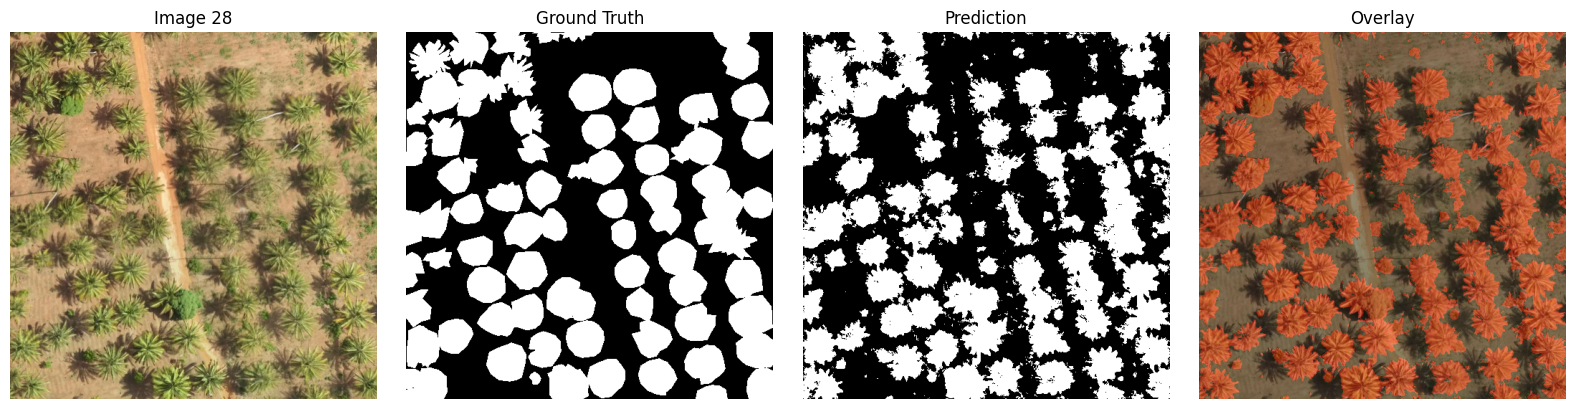

=== Image 6 ===


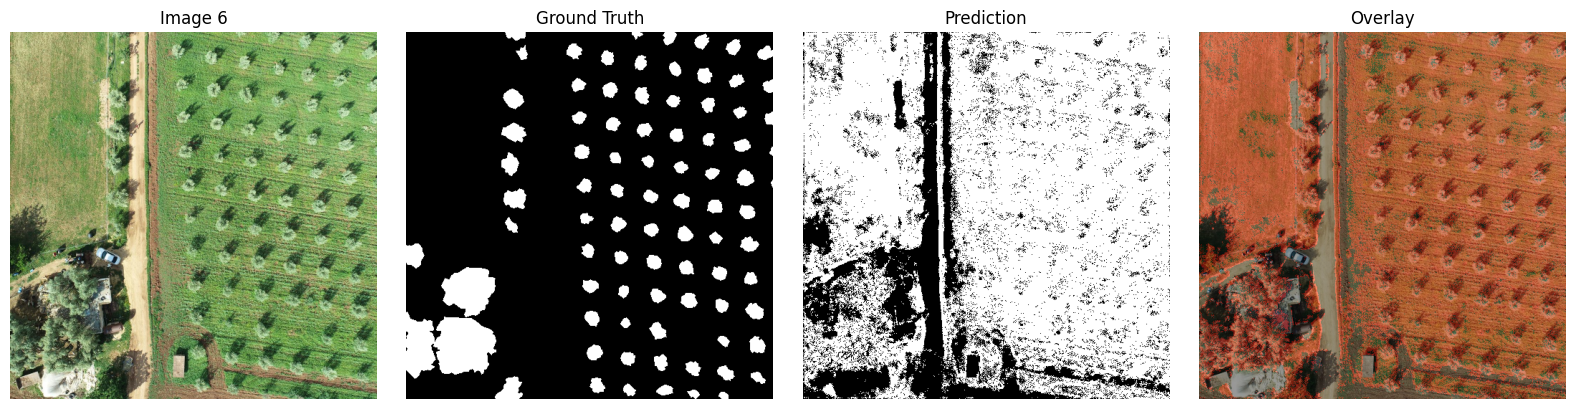

=== Image 70 ===


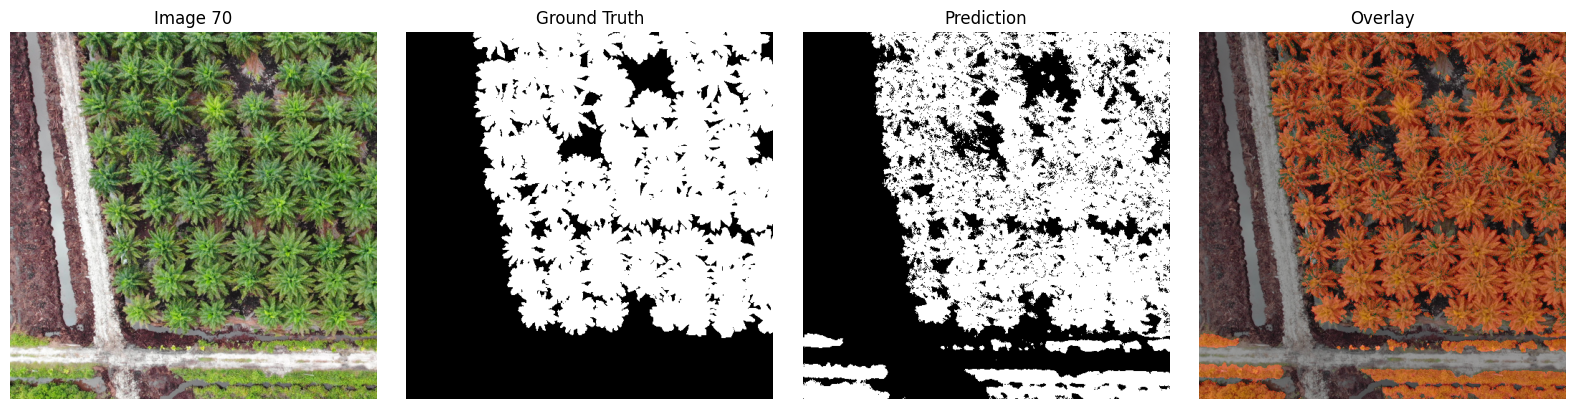

=== Image 62 ===


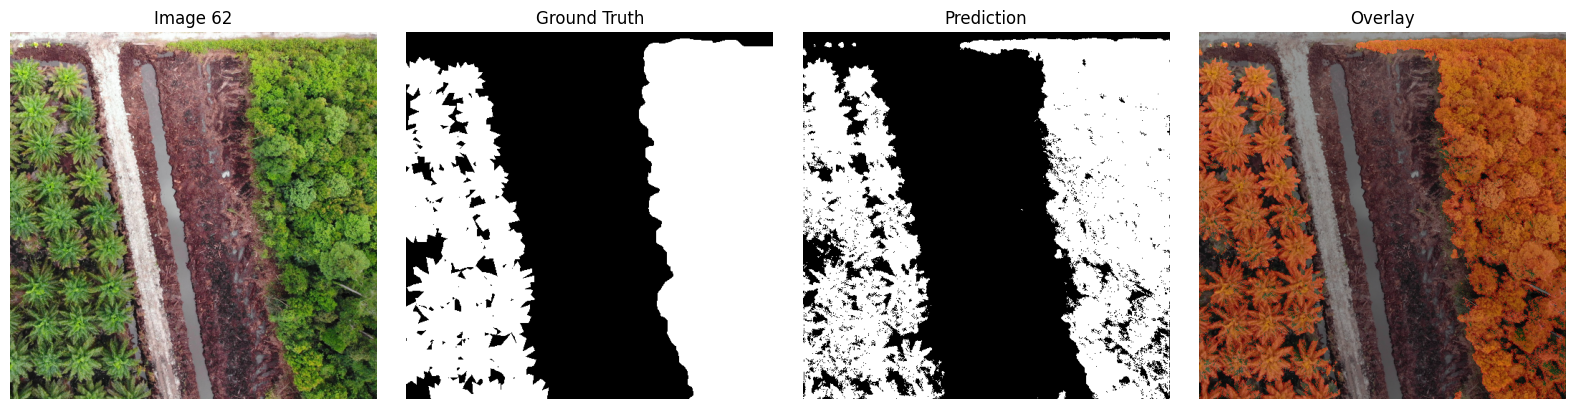

=== Image 57 ===


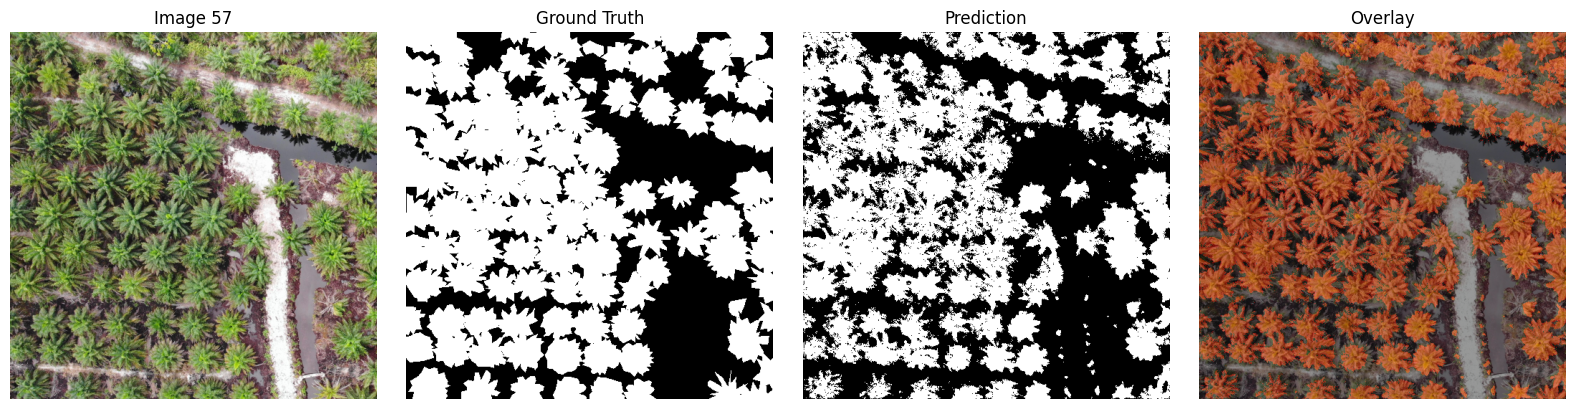

In [7]:

for _ in range(5):
    idx = random.randint(0, len(dataset) - 1)
    t(f"Image {idx}")

    img_t, mask_t = dataset[idx]

    img = img_t.permute(1, 2, 0).numpy()
    mask = mask_t.squeeze().numpy()

    with torch.no_grad():
        pred = model(img_t.unsqueeze(0)).cpu().squeeze().numpy()

    pred_bin = (pred > 0.5).astype(np.uint8)

    # show_image(img, f"Image {idx}")
    # show_mask(mask, "Ground Truth")
    # show_mask(pred_bin, "Prediction")
    # show_overlay(img, pred_bin, 0.4, "Overlay")


    titles = [f"Image {idx}", "Ground Truth", "Prediction", "Overlay"]

    if img.max() <= 1.0:
        base = (img * 255).astype(np.uint8)
    else:
        base = img.astype(np.uint8)

    mask_u8 = (mask > 0.5).astype(np.uint8) * 255
    pred_u8 = pred_bin * 255

    mask_rgb = np.zeros_like(base)
    mask_rgb[:, :, 0] = mask_u8

    pred_rgb = np.zeros_like(base)
    pred_rgb[:, :, 0] = pred_u8

    overlay = cv2.addWeighted(base, 0.6, pred_rgb, 0.4, 0)

    show_side_by_side(base, mask_u8, pred_u8, overlay,
                      titles = titles,
                      cmaps = [None, "gray", "gray", None]
                      )